# FAQ Category Classification Model Comparison

This notebook trains and compares several ML models for predicting the FAQ `category` from a user question.

Models included:
- Logistic Regression
- MLP Classifier
- Linear SVM
- KNN baseline


In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import preprocess_text

DATA_PATH = PROJECT_ROOT / "data" / "final" / "faq_dataset_final_merged.jsonl"
MODEL_DIR = PROJECT_ROOT / "models"
RESULT_DIR = PROJECT_ROOT / "ML_train" / "results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2

DATA_PATH

PosixPath('/Users/jinyu/workspace/xmum-freshman-chatbot/data/final/faq_dataset_final_merged.jsonl')

## Load Dataset

In [2]:
def load_jsonl(path: Path) -> pd.DataFrame:
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)


df = load_jsonl(DATA_PATH)
df = df[["question", "category", "intent", "keywords"]].dropna(subset=["question", "category"])
df["question"] = df["question"].astype(str)
df["category"] = df["category"].astype(str)
df["processed_question"] = df["question"].apply(preprocess_text)

print(f"Rows: {len(df)}")
print(f"Categories: {df['category'].nunique()}")
df.head()

Rows: 622
Categories: 8


,question,category,intent,keywords,processed_question
0,How to apply for school certificate via email?,Academic Affairs,ask_procedure,"[email application, certificate, school proof,...",apply school certificate email
1,What academic issues does the A3-702 Academic ...,Academic Affairs,ask_definition,"[academic affairs, course registration, grade ...",academic issues does a3 702 academic affairs o...
2,What are the business hours of the A3-702 Acad...,Academic Affairs,ask_hours,"[office hours, academic affairs, A3-702, busin...",business hours a3 702 academic affairs office
3,Do I need to bring my league member file and p...,Academic Affairs,ask_procedure,"[league member file, personal file, archive st...",need bring league member file personal file sc...
4,How does Xiamen University Malaysia handle you...,Academic Affairs,ask_procedure,"[party membership, youth league files, persona...",does xiamen university malaysia handle youth l...


## Category Distribution

,count
category,
Campus life,193
Accommodation & Living,94
Academic Affairs,71
Registration & Orientation,64
Transportation,53
Campus Services,52
Finance & Fees,52
University Platforms & IT Support,43


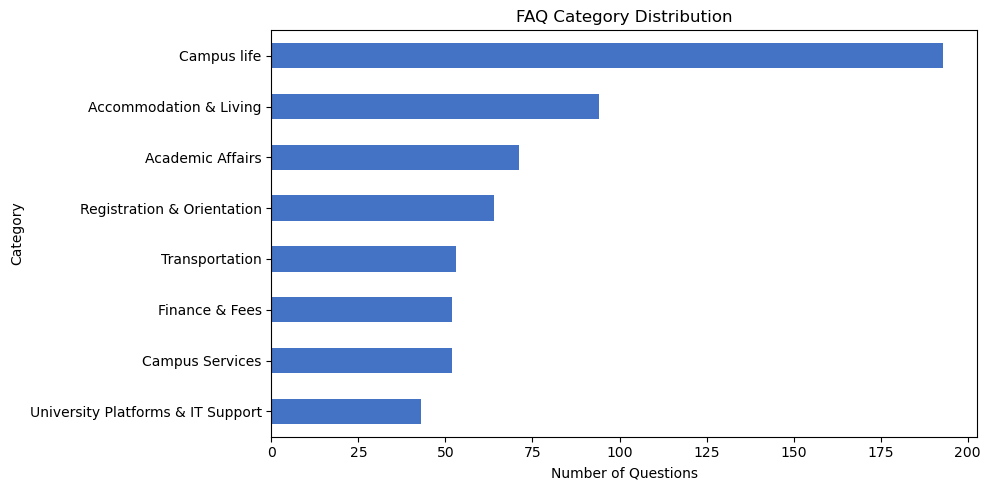

In [3]:
category_counts = df["category"].value_counts()
display(category_counts.to_frame("count"))

plt.figure(figsize=(10, 5))
category_counts.sort_values().plot(kind="barh", color="#4472C4")
plt.title("FAQ Category Distribution")
plt.xlabel("Number of Questions")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## Train/Test Split

In [4]:
X = df["question"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 497
Test size: 125


## Build Model Pipelines

Each pipeline uses the project preprocessing function first, then TF-IDF vectorization, then a classifier.

In [5]:
def make_pipeline(classifier):
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    preprocessor=preprocess_text,
                    lowercase=False,
                    token_pattern=r"(?u)\b\w+\b",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_df=0.95,
                ),
            ),
            ("classifier", classifier),
        ]
    )


models = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    ),
    "MLP": make_pipeline(
        MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            alpha=0.0005,
            early_stopping=False,
            max_iter=600,
            random_state=RANDOM_STATE,
        )
    ),
    "SVM": make_pipeline(
        LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    ),
    "KNN": make_pipeline(
        KNeighborsClassifier(
            n_neighbors=5,
            weights="distance",
            metric="cosine",
        )
    ),
}

models

{'Logistic Regression': Pipeline(steps=[('tfidf',
                  TfidfVectorizer(lowercase=False, max_df=0.95, min_df=2,
                                  ngram_range=(1, 2),
                                  preprocessor=<function preprocess_text at 0x168384700>,
                                  token_pattern='(?u)\\b\\w+\\b')),
                 ('classifier',
                  LogisticRegression(class_weight='balanced', max_iter=2000,
                                     random_state=42))]),
 'MLP': Pipeline(steps=[('tfidf',
                  TfidfVectorizer(lowercase=False, max_df=0.95, min_df=2,
                                  ngram_range=(1, 2),
                                  preprocessor=<function preprocess_text at 0x168384700>,
                                  token_pattern='(?u)\\b\\w+\\b')),
                 ('classifier',
                  MLPClassifier(alpha=0.0005, hidden_layer_sizes=(128, 64),
                                max_iter=600, random_state=42))]),
 '

## Train and Evaluate

In [6]:
results = []
predictions = {}
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    trained_models[name] = model
    predictions[name] = y_pred

    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        }
    )

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
display(results_df)

results_df.to_csv(RESULT_DIR / "category_model_comparison_metrics.csv", index=False)

Training Logistic Regression...
Training MLP...
Training SVM...
Training KNN...


,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,SVM,0.752,0.721144,0.704154,0.708689,0.757948
1,Logistic Regression,0.736,0.711343,0.693835,0.696424,0.740521
2,KNN,0.728,0.697222,0.666912,0.677131,0.726355
3,MLP,0.728,0.690438,0.660013,0.666725,0.728453


## Visualize Model Comparison

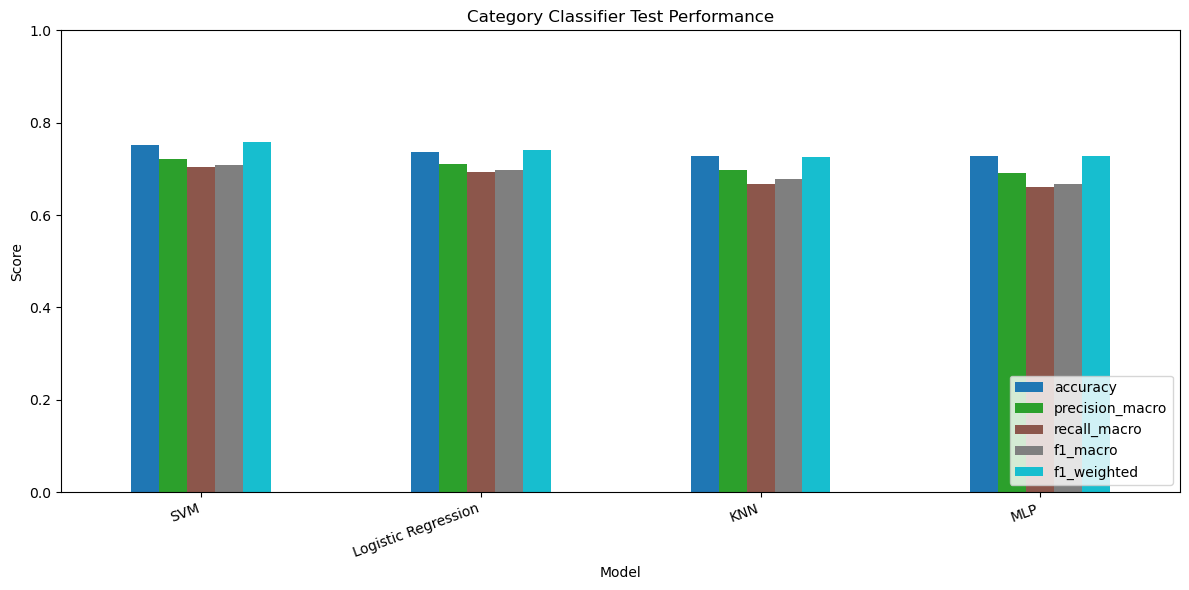

In [7]:
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"]

ax = results_df.set_index("model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(12, 6),
    ylim=(0, 1),
    colormap="tab10",
)
ax.set_title("Category Classifier Test Performance")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(RESULT_DIR / "category_model_comparison_bar.png", dpi=160)
plt.show()

## Classification Reports

In [8]:
for name in results_df["model"]:
    print("=" * 90)
    print(name)
    print(classification_report(y_test, predictions[name], zero_division=0))

SVM
                                   precision    recall  f1-score   support

                 Academic Affairs       0.79      0.79      0.79        14
           Accommodation & Living       0.88      0.79      0.83        19
                  Campus Services       0.36      0.50      0.42        10
                      Campus life       0.85      0.87      0.86        39
                   Finance & Fees       0.67      0.60      0.63        10
       Registration & Orientation       0.90      0.69      0.78        13
                   Transportation       0.73      0.73      0.73        11
University Platforms & IT Support       0.60      0.67      0.63         9

                         accuracy                           0.75       125
                        macro avg       0.72      0.70      0.71       125
                     weighted avg       0.77      0.75      0.76       125

Logistic Regression
                                   precision    recall  f1-score   suppor

## Best Model Confusion Matrix

Best model by macro F1: SVM


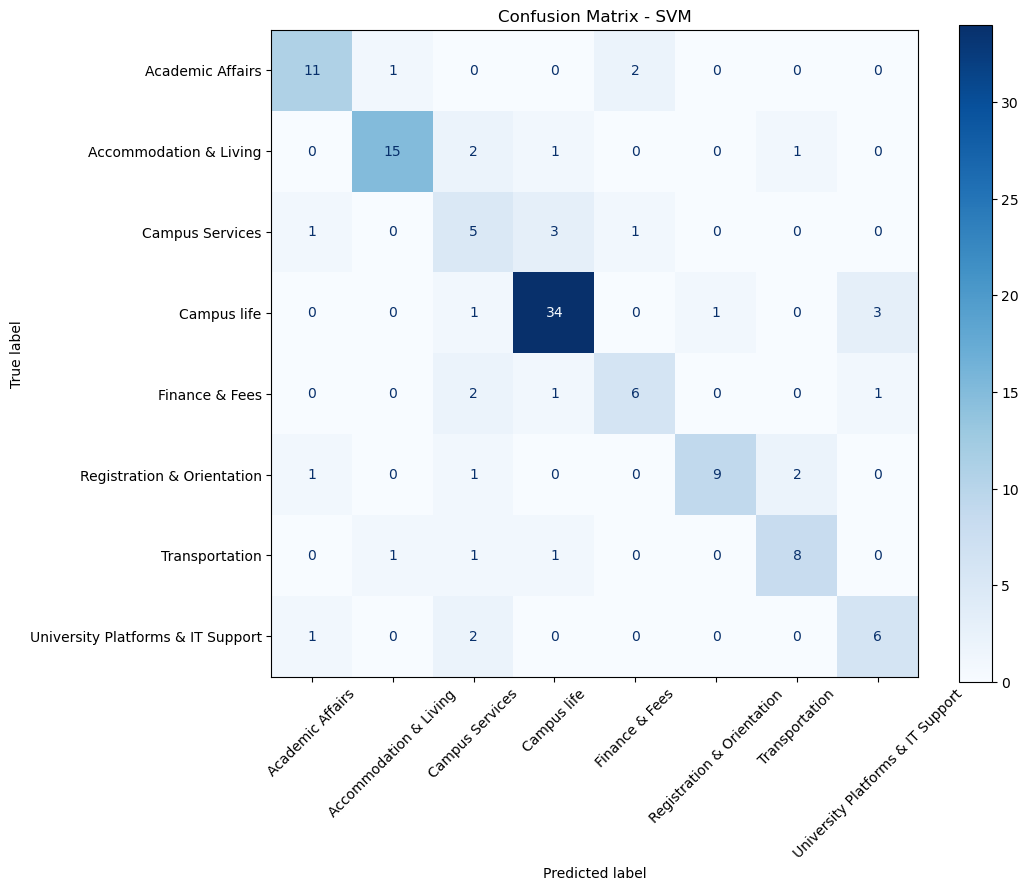

In [9]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]

print(f"Best model by macro F1: {best_model_name}")

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    labels=sorted(y.unique()),
    xticks_rotation=45,
    cmap="Blues",
    ax=ax,
)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig(RESULT_DIR / "best_category_model_confusion_matrix.png", dpi=160)
plt.show()

## Save Best Model

In [10]:
model_path = MODEL_DIR / "best_category_classifier.joblib"
metadata_path = MODEL_DIR / "best_category_classifier_metadata.json"

joblib.dump(best_model, model_path)

metadata = {
    "best_model": best_model_name,
    "data_path": str(DATA_PATH.relative_to(PROJECT_ROOT)),
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "metrics": results_df.to_dict(orient="records"),
    "labels": sorted(y.unique()),
}

metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved best model to: {model_path}")
print(f"Saved metadata to: {metadata_path}")

Saved best model to: /Users/jinyu/workspace/xmum-freshman-chatbot/models/best_category_classifier.joblib
Saved metadata to: /Users/jinyu/workspace/xmum-freshman-chatbot/models/best_category_classifier_metadata.json


## Load Model and Predict Sample Questions

In [11]:
loaded_model = joblib.load(model_path)

sample_questions = [
    "How can I reset my Moodle password?",
    "Where can I pay my tuition fee?",
    "When is the airport pickup for new students?",
    "How do I apply for hostel maintenance?",
    "Where is the academic affairs office?",
]

sample_predictions = pd.DataFrame(
    {
        "question": sample_questions,
        "processed_question": [preprocess_text(q) for q in sample_questions],
        "predicted_category": loaded_model.predict(sample_questions),
    }
)

display(sample_predictions)

,question,processed_question,predicted_category
0,How can I reset my Moodle password?,reset moodle password,University Platforms & IT Support
1,Where can I pay my tuition fee?,pay tuition fee,Finance & Fees
2,When is the airport pickup for new students?,airport pickup new students,Registration & Orientation
3,How do I apply for hostel maintenance?,apply hostel maintenance,Accommodation & Living
4,Where is the academic affairs office?,academic affairs office,Finance & Fees
